# Ward selection: Ntabankulu

This notebook selects the ward for microgrid siting. Classical solvers solve the siting
problem of each ward, then the results are compared. `pilot.ipynb` solves the selected ward
with QAOA.

**Criterion.** The plan builds `n_sites` microgrids from `n_candidates` candidate sites (the
qubits). The best ward is the ward where the optimal selection serves the most far-from-grid
demand. Each ward is solved two ways:

|                       | candidate sites                                         | solver                                      |
|-----------------------|---------------------------------------------------------|---------------------------------------------|
| **candidate problem** | the `n_candidates` sites from `candidate_sites` (QAOA input) | `solve_exact`: search of all K-subsets  |
| **full problem**      | all far-from-grid demand nodes                          | `solve_milp`: mixed-integer program (HiGHS) |

The full problem gives an upper bound. The difference between the two is the cost of the
qubit limit. The greedy and QUBO optima show where the problem is difficult enough for a
quantum solver.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quackathon.classical import solve_exact
from quackathon.config import PilotConfig
from quackathon.pipeline import build_pilot
from quackathon.screening import Municipality, allocate_sites, rank_sweep, screen_wards
from quackathon import viz

viz.use_style()
%config InlineBackend.figure_format = "retina"
pd.set_option("display.precision", 2)

In [2]:
# Same config as pilot.ipynb. This notebook selects ward_no.
cfg = PilotConfig(
    grid_distance_m=2_000,
    n_sites=3,
    n_candidates=12,
    service_radius_m=1_500,
    grid_source="gridfinder",
)
muni = Municipality.load(cfg)
print(f"{len(muni.wards)} wards, {len(muni.buildings):,} buildings, {len(muni.grid)} grid lines ({cfg.grid_source})")

19 wards, 122,239 buildings, 605 grid lines (gridfinder)


## 1. Screen all wards

Units are kWh/day, except shares and gaps.
- `served`: optimum of the candidate problem. The rank uses this value.
- `full_served`: optimum when each far-from-grid demand node can be a site.
- `candidate_gap`: share of `full_served` that the candidate-site limit loses.

A ward is not eligible (`eligible = False`) if it has fewer far-from-grid demand nodes than
`n_candidates`. Most settlements in these wards are near the grid.

In [3]:
screen = screen_wards(muni, cfg)
screen[["buildings", "far_nodes", "far_demand", "eligible", "served", "full_served",
        "served_share", "candidate_gap", "rank"]]

,buildings,far_nodes,far_demand,eligible,served,full_served,served_share,candidate_gap,rank
ward,,,,,,,,,
4,5781,86,574.12,True,441.12,441.12,0.77,0.00,1
1,5921,166,673.88,True,371.12,388.62,0.55,0.05,2
16,8386,176,588.50,True,264.00,264.00,0.45,0.00,3
5,4609,83,432.25,True,256.25,256.25,0.59,0.00,4
9,6956,77,306.50,True,230.25,230.25,0.75,0.00,5
19,8346,69,271.00,True,216.88,256.38,0.80,0.15,6
14,6594,43,233.25,True,205.38,207.50,0.88,0.01,7
8,6259,39,159.50,True,150.25,157.62,0.94,0.05,8
13,8284,47,245.12,True,149.50,149.50,0.61,0.00,9


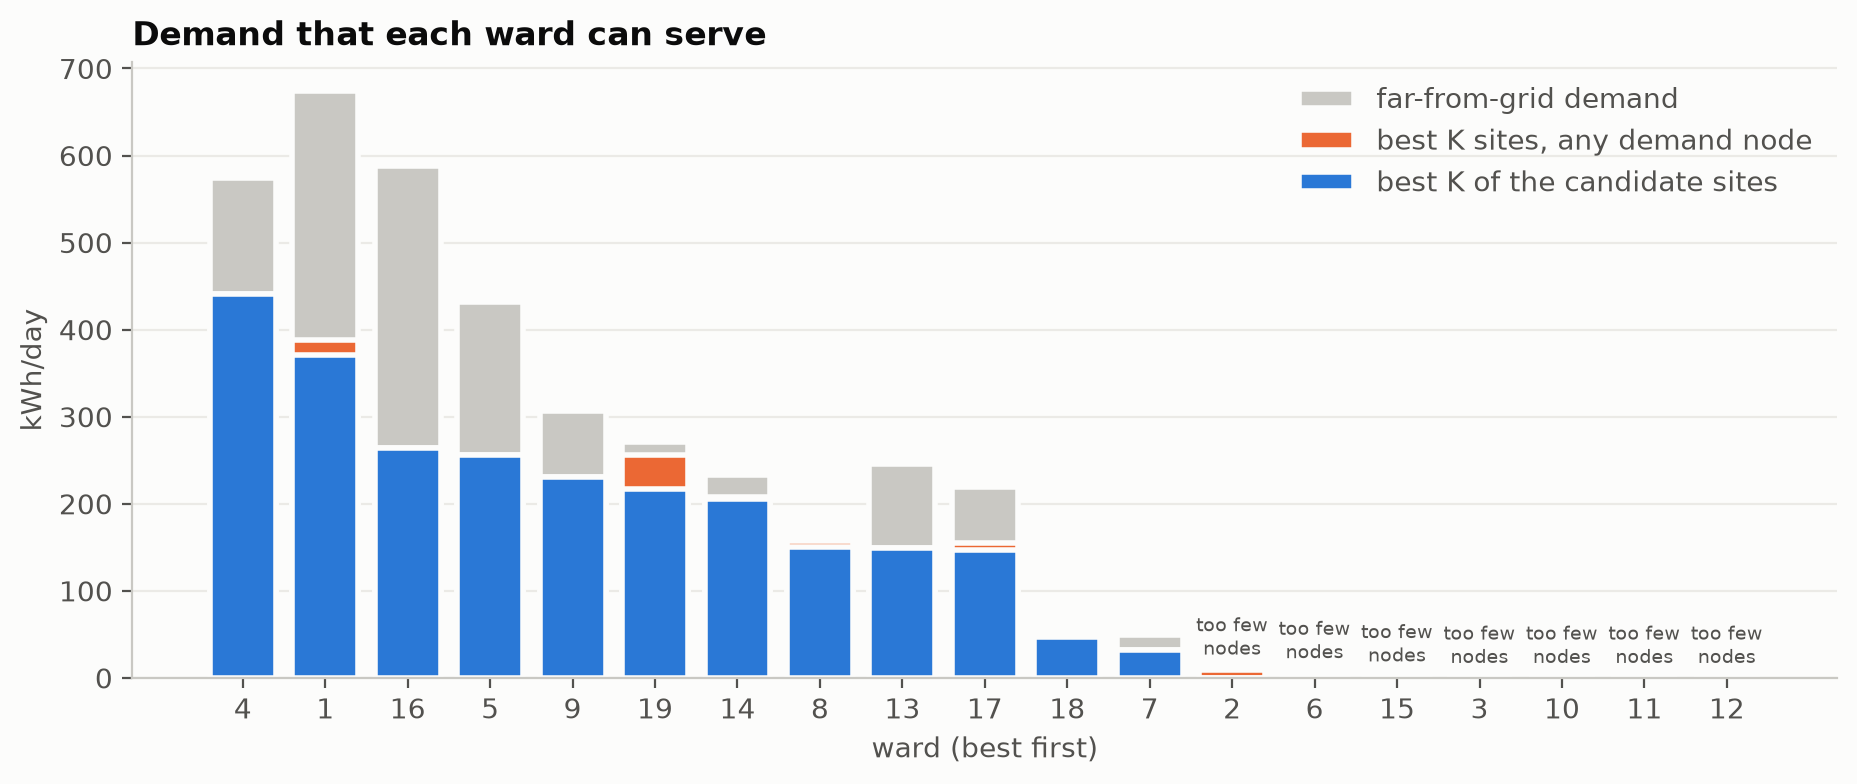

In [4]:
viz.plot_ward_screening(screen)
plt.show()

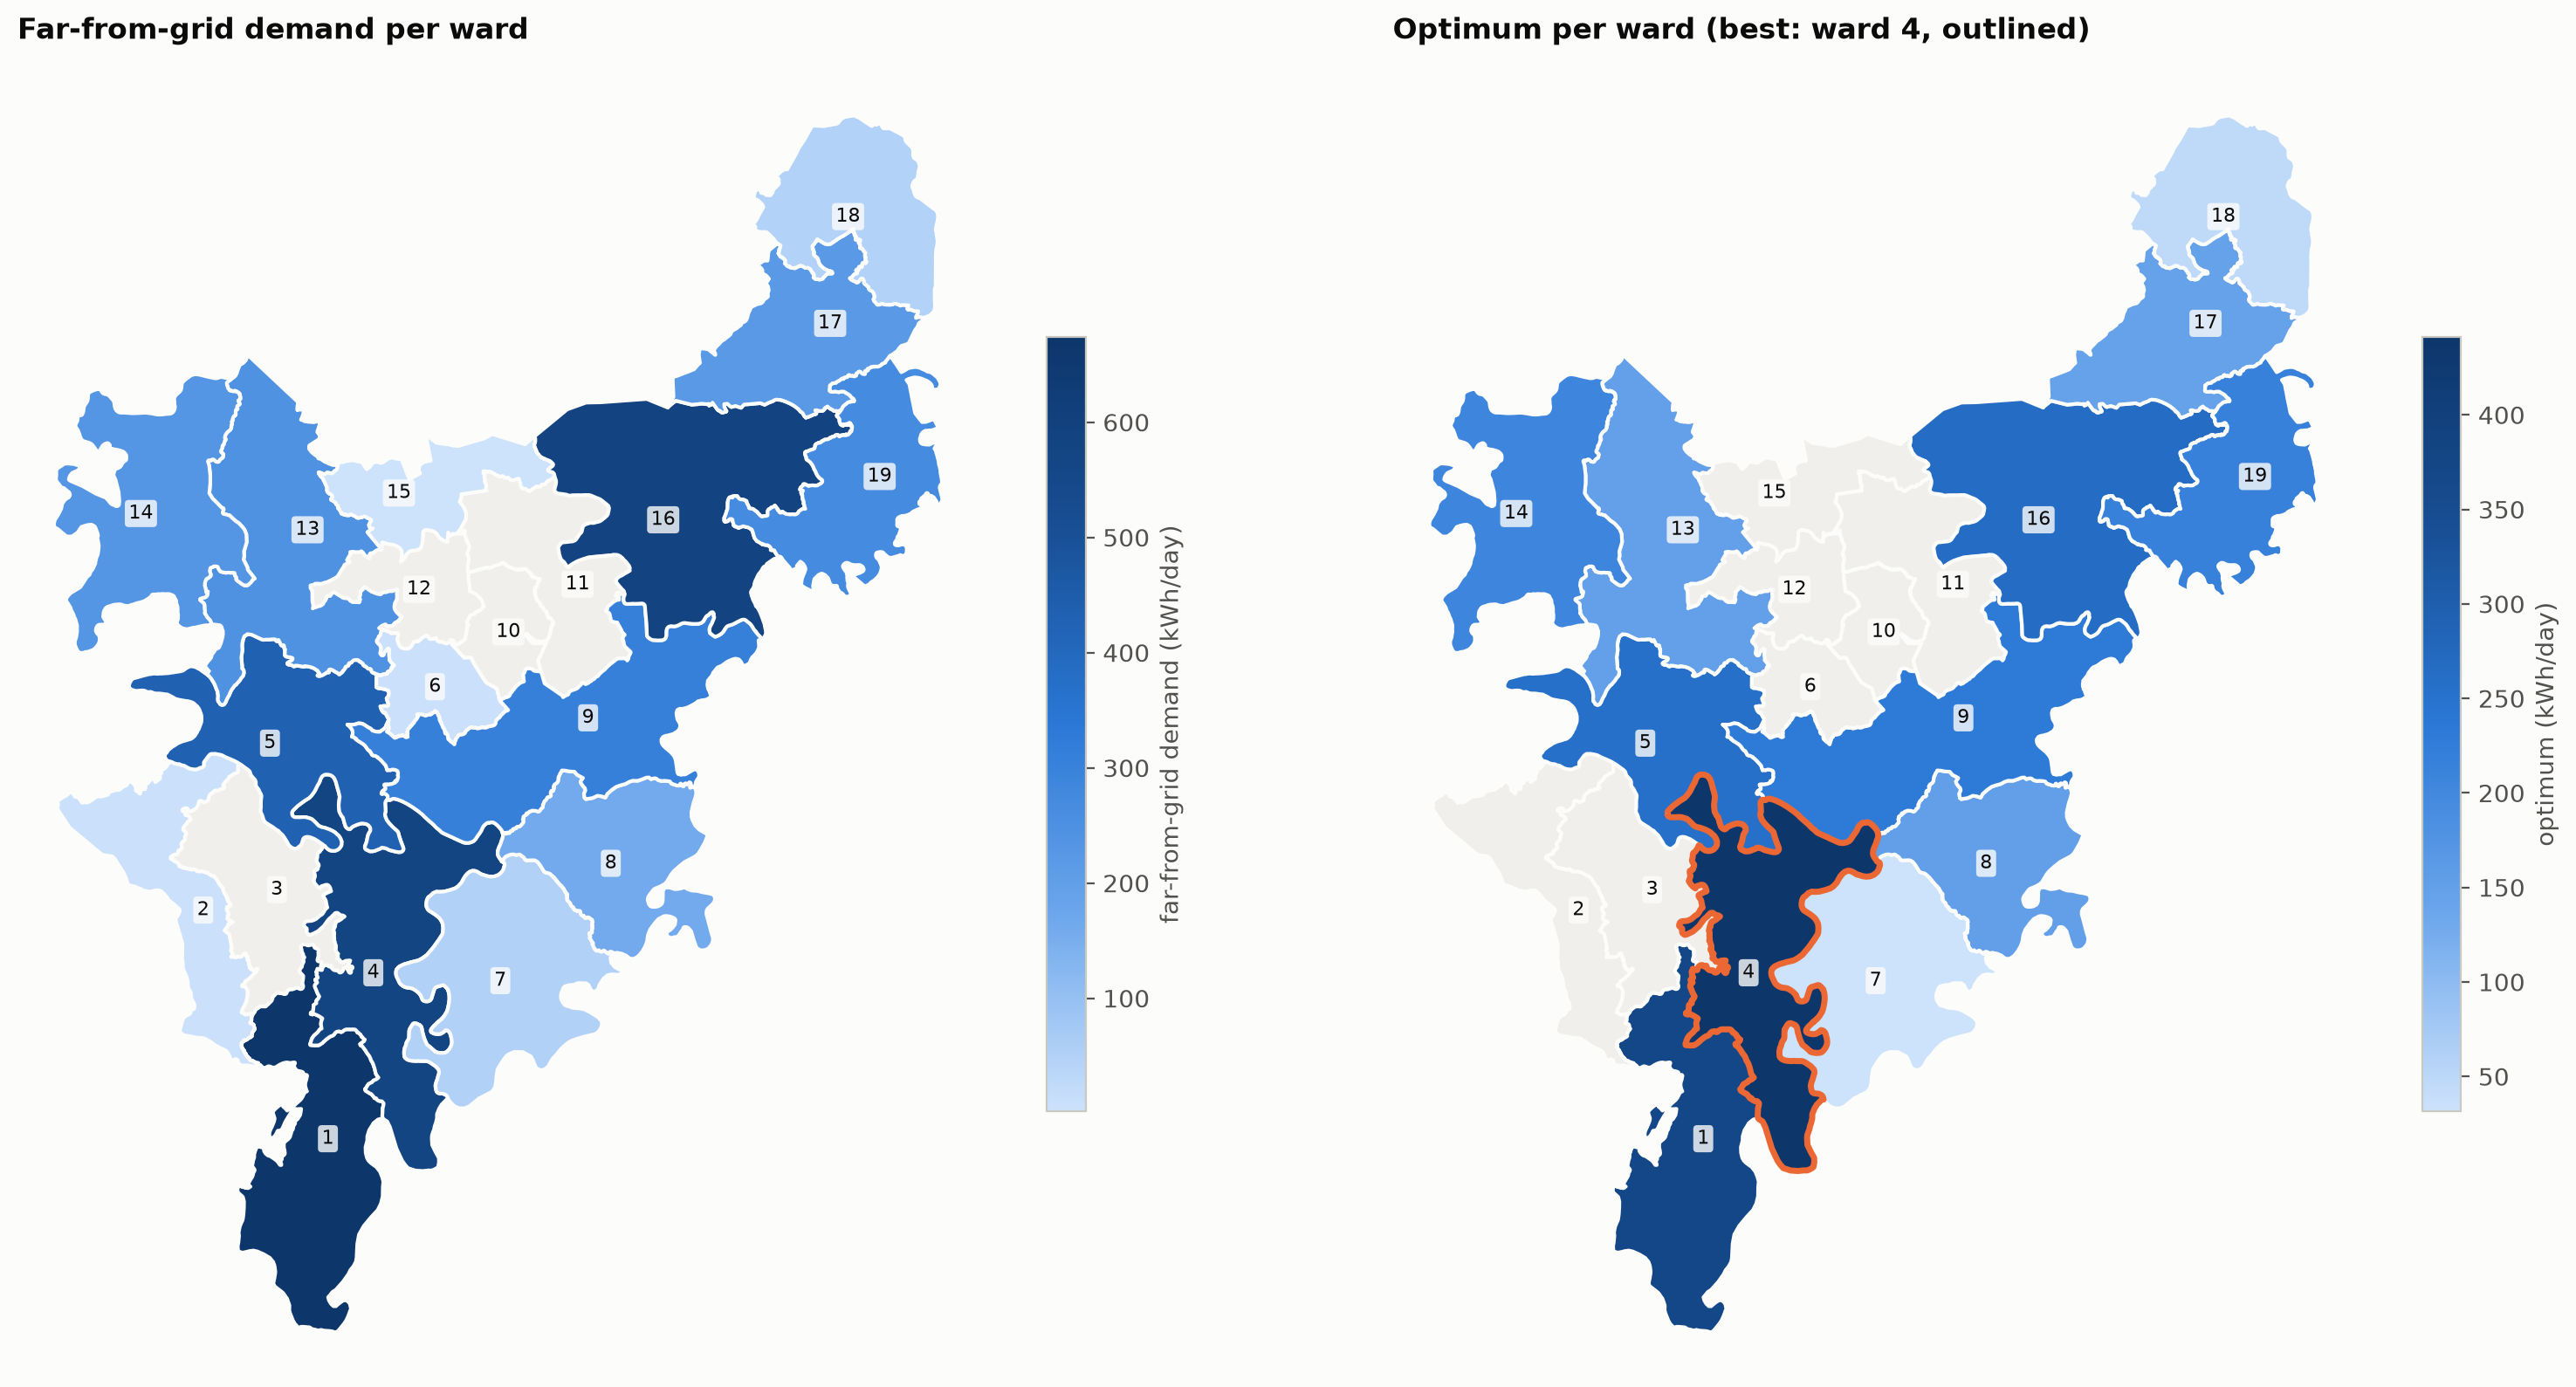

In [5]:
best_ward = int(screen.index[0])
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
viz.plot_ward_choropleth(muni.wards, screen["far_demand"].where(screen["far_demand"] > 0),
                         "far-from-grid demand (kWh/day)", "Far-from-grid demand per ward", ax=axes[0])
viz.plot_ward_choropleth(muni.wards, screen["served"], "optimum (kWh/day)",
                         f"Optimum per ward (best: ward {best_ward}, outlined)",
                         highlight=best_ward, ax=axes[1])
plt.tight_layout()
plt.show()

## 2. Problem difficulty

Served demand is the main criterion. Three more values show if the problem of a ward is
suitable for a quantum solver:
- **Greedy gap** (`greedy_gap > 0`). Greedy adds the best site one at a time. If greedy finds
  the optimum, a better solver gives no improvement.
- **QUBO exactness** (`qubo_exact`). The QUBO optimum must be equal to the exact optimum.
  If not, a perfect QUBO solver still gives an incorrect plan.
- **Candidate gap.** A small gap shows that the qubit limit loses little demand.

In [6]:
eligible = screen[screen["eligible"]].copy()
eligible["qubo_exact"] = np.isclose(eligible["qubo_served"], eligible["served"])
eligible[["served", "greedy_served", "greedy_gap", "qubo_served", "qubo_exact", "candidate_gap", "rank"]]

,served,greedy_served,greedy_gap,qubo_served,qubo_exact,candidate_gap,rank
ward,,,,,,,
4,441.12,413.75,0.06,441.12,True,0.00,1
1,371.12,361.25,0.03,371.12,True,0.05,2
16,264.00,253.00,0.04,264.00,True,0.00,3
5,256.25,256.25,0.00,256.25,True,0.00,4
9,230.25,219.38,0.05,230.25,True,0.00,5
19,216.88,209.50,0.03,216.88,True,0.15,6
14,205.38,205.38,0.00,205.38,True,0.01,7
8,150.25,141.25,0.06,150.25,True,0.05,8
13,149.50,149.50,0.00,149.50,True,0.00,9


## 3. Sensitivity of the ranking

The service radius and the grid-distance cut-off are estimates. Each column is one screen
with one combination of the two values. Each cell is the rank of the ward (1 = best). A blank
cell shows that the ward is not eligible for that config. A ward that stays near the top in
all columns is a robust selection.

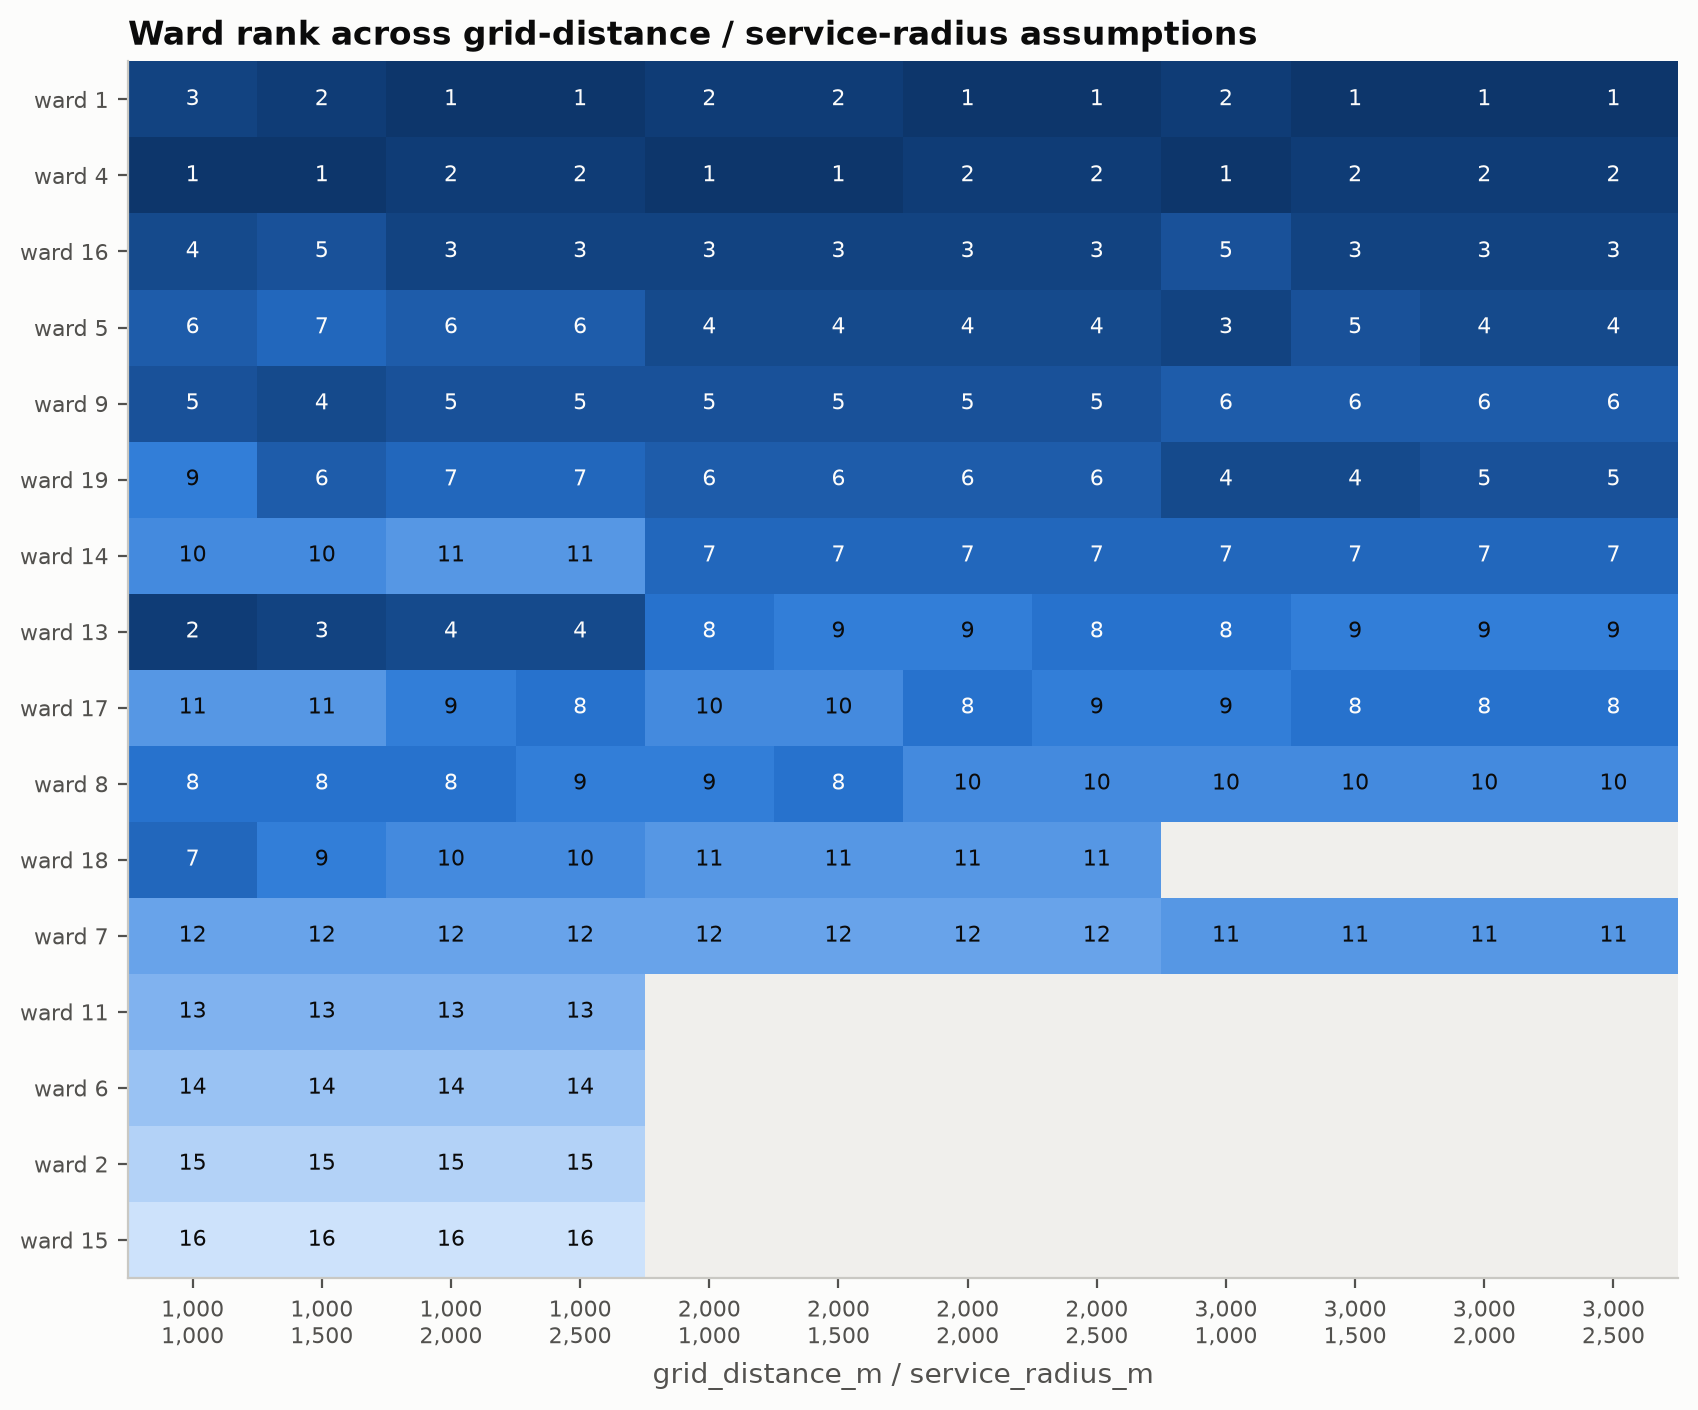

,times_best,times_top3,median_rank,worst_rank
ward,,,,
1,7,12,1.0,3.0
4,5,12,2.0,2.0
16,0,9,3.0,5.0
13,0,2,8.0,9.0
5,0,1,4.0,7.0
9,0,0,5.0,6.0


In [7]:
RADII = [1_000, 1_500, 2_000, 2_500]
GRID_DISTANCES = [1_000, 2_000, 3_000]
ranks = rank_sweep(muni, cfg, grid_distance_m=GRID_DISTANCES, service_radius_m=RADII)

viz.plot_rank_heatmap(ranks, title="Ward rank across grid-distance / service-radius assumptions")
plt.show()

summary = pd.DataFrame({
    "times_best": (ranks == 1).sum(axis=1),
    "times_top3": (ranks <= 3).sum(axis=1),
    "median_rank": ranks.astype(float).median(axis=1),
    "worst_rank": ranks.astype(float).max(axis=1),
}).sort_values(["times_best", "times_top3", "median_rank"], ascending=[False, False, True])
summary.head(6)

## 4. Sites without ward boundaries

The MILP selects the best `n_total` sites from all far-from-grid demand nodes in Ntabankulu.
A site can serve demand in a different ward. Wards with several sites have the largest
demand clusters. If more than one site reaches a demand node, the nearest site gets the credit.

In [8]:
N_TOTAL = 10
alloc = allocate_sites(muni, cfg, N_TOTAL)
far = muni.far_nodes(cfg)
total_served = alloc["serves_kwh_day"].sum()
print(f"{N_TOTAL} sites serve {total_served:.0f} of {far['demand_kwh_day'].sum():.0f} kWh/day "
      f"of far-from-grid demand in the municipality")
by_ward = alloc.groupby("WardNo").agg(sites=("serves_kwh_day", "size"), serves_kwh_day=("serves_kwh_day", "sum"))
by_ward.sort_values("serves_kwh_day", ascending=False)

10 sites serve 1319 of 3818 kWh/day of far-from-grid demand in the municipality


,sites,serves_kwh_day
WardNo,,
4,2,365.12
1,2,298.88
5,2,196.62
19,1,128.88
14,1,114.38
16,1,109.25
9,1,105.50


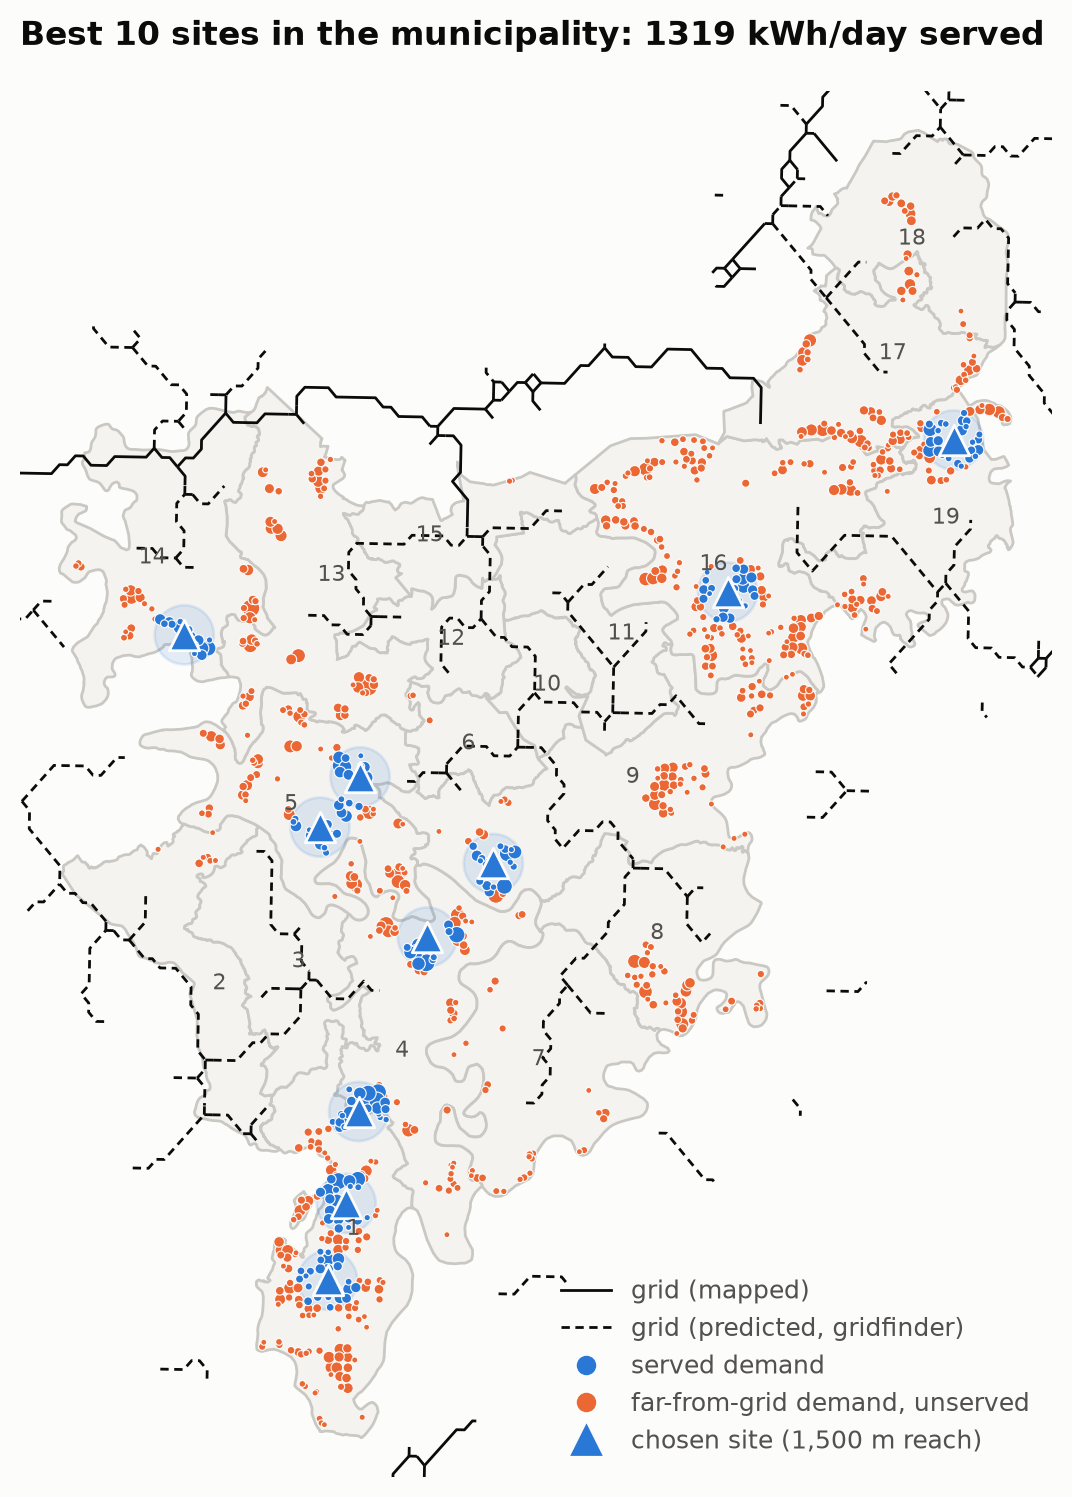

In [9]:
viz.plot_allocation(muni.wards, muni.grid, far, alloc, cfg.service_radius_m,
                    title=f"Best {N_TOTAL} sites in the municipality: {total_served:.0f} kWh/day served")
plt.show()

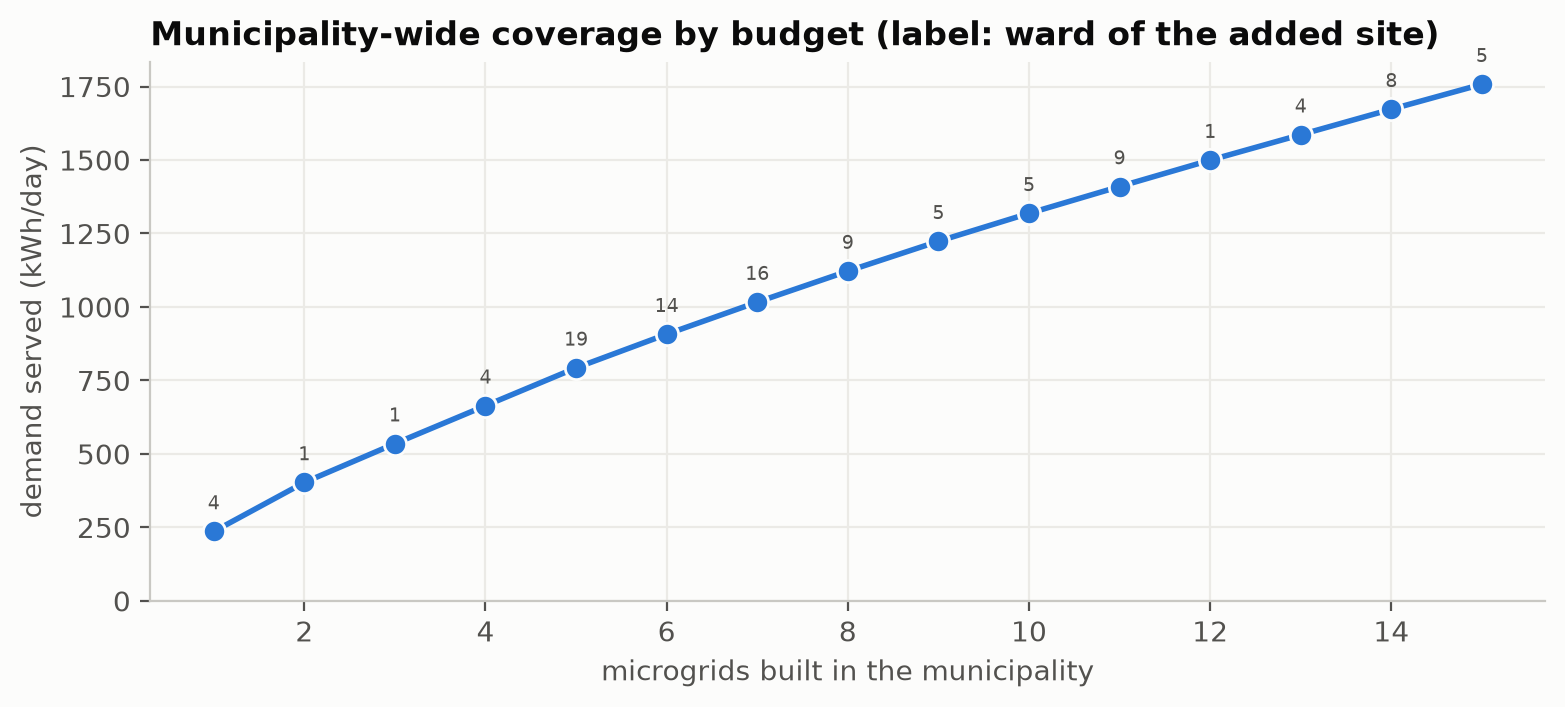

In [10]:
# Each extra site serves less than the one before it. Labels show which ward hosts the
# newly added site (the MILP re-optimises every site at each budget, so earlier sites can move).
budgets = range(1, 16)
served_by_budget, new_ward = [], []
prev = set()
for n in budgets:
    a = allocate_sites(muni, cfg, n)
    served_by_budget.append(a["serves_kwh_day"].sum())
    wards_now = list(a["WardNo"])
    added = pd.Series(wards_now).value_counts().sub(pd.Series(list(prev)).value_counts(), fill_value=0)
    new_ward.append(", ".join(str(w) for w in added[added > 0].index))
    prev = wards_now

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(list(budgets), served_by_budget, color=viz.SERVED, marker="o", markersize=8, markeredgecolor=viz.SURFACE)
for n, s, w in zip(budgets, served_by_budget, new_ward):
    ax.annotate(w, (n, s), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=7,
                color=viz.INK_SECONDARY)
ax.set_xlabel("microgrids built in the municipality")
ax.set_ylabel("demand served (kWh/day)")
ax.set_ylim(bottom=0)
ax.set_title("Municipality-wide coverage by budget (label: ward of the added site)")
plt.show()

## 5. Result

The selected ward and the second ward, each with its optimal selection.

**Results at the default config** (2 km cut-off, 1.5 km radius, K = 3 of 12):
- **Ward 4** has the highest optimum, approximately 440 kWh/day. It ranks 1st or 2nd in all
  12 configs. Greedy is approximately 6% below the optimum. The QUBO optimum is exact.
  Ward 4 is the selected ward.
- **Ward 1** is second, approximately 370 kWh/day. It has the largest far-from-grid demand.
  It ranks 1st in 7 of 12 configs, mostly at a service radius of 2 km or more. It never ranks
  below 3rd.
- Wards 3, 10, 11 and 12 have no settlements beyond 2 km of the gridfinder grid. They are not
  eligible.
- The municipality-wide MILP agrees. The first sites go to wards 4 and 1.

/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


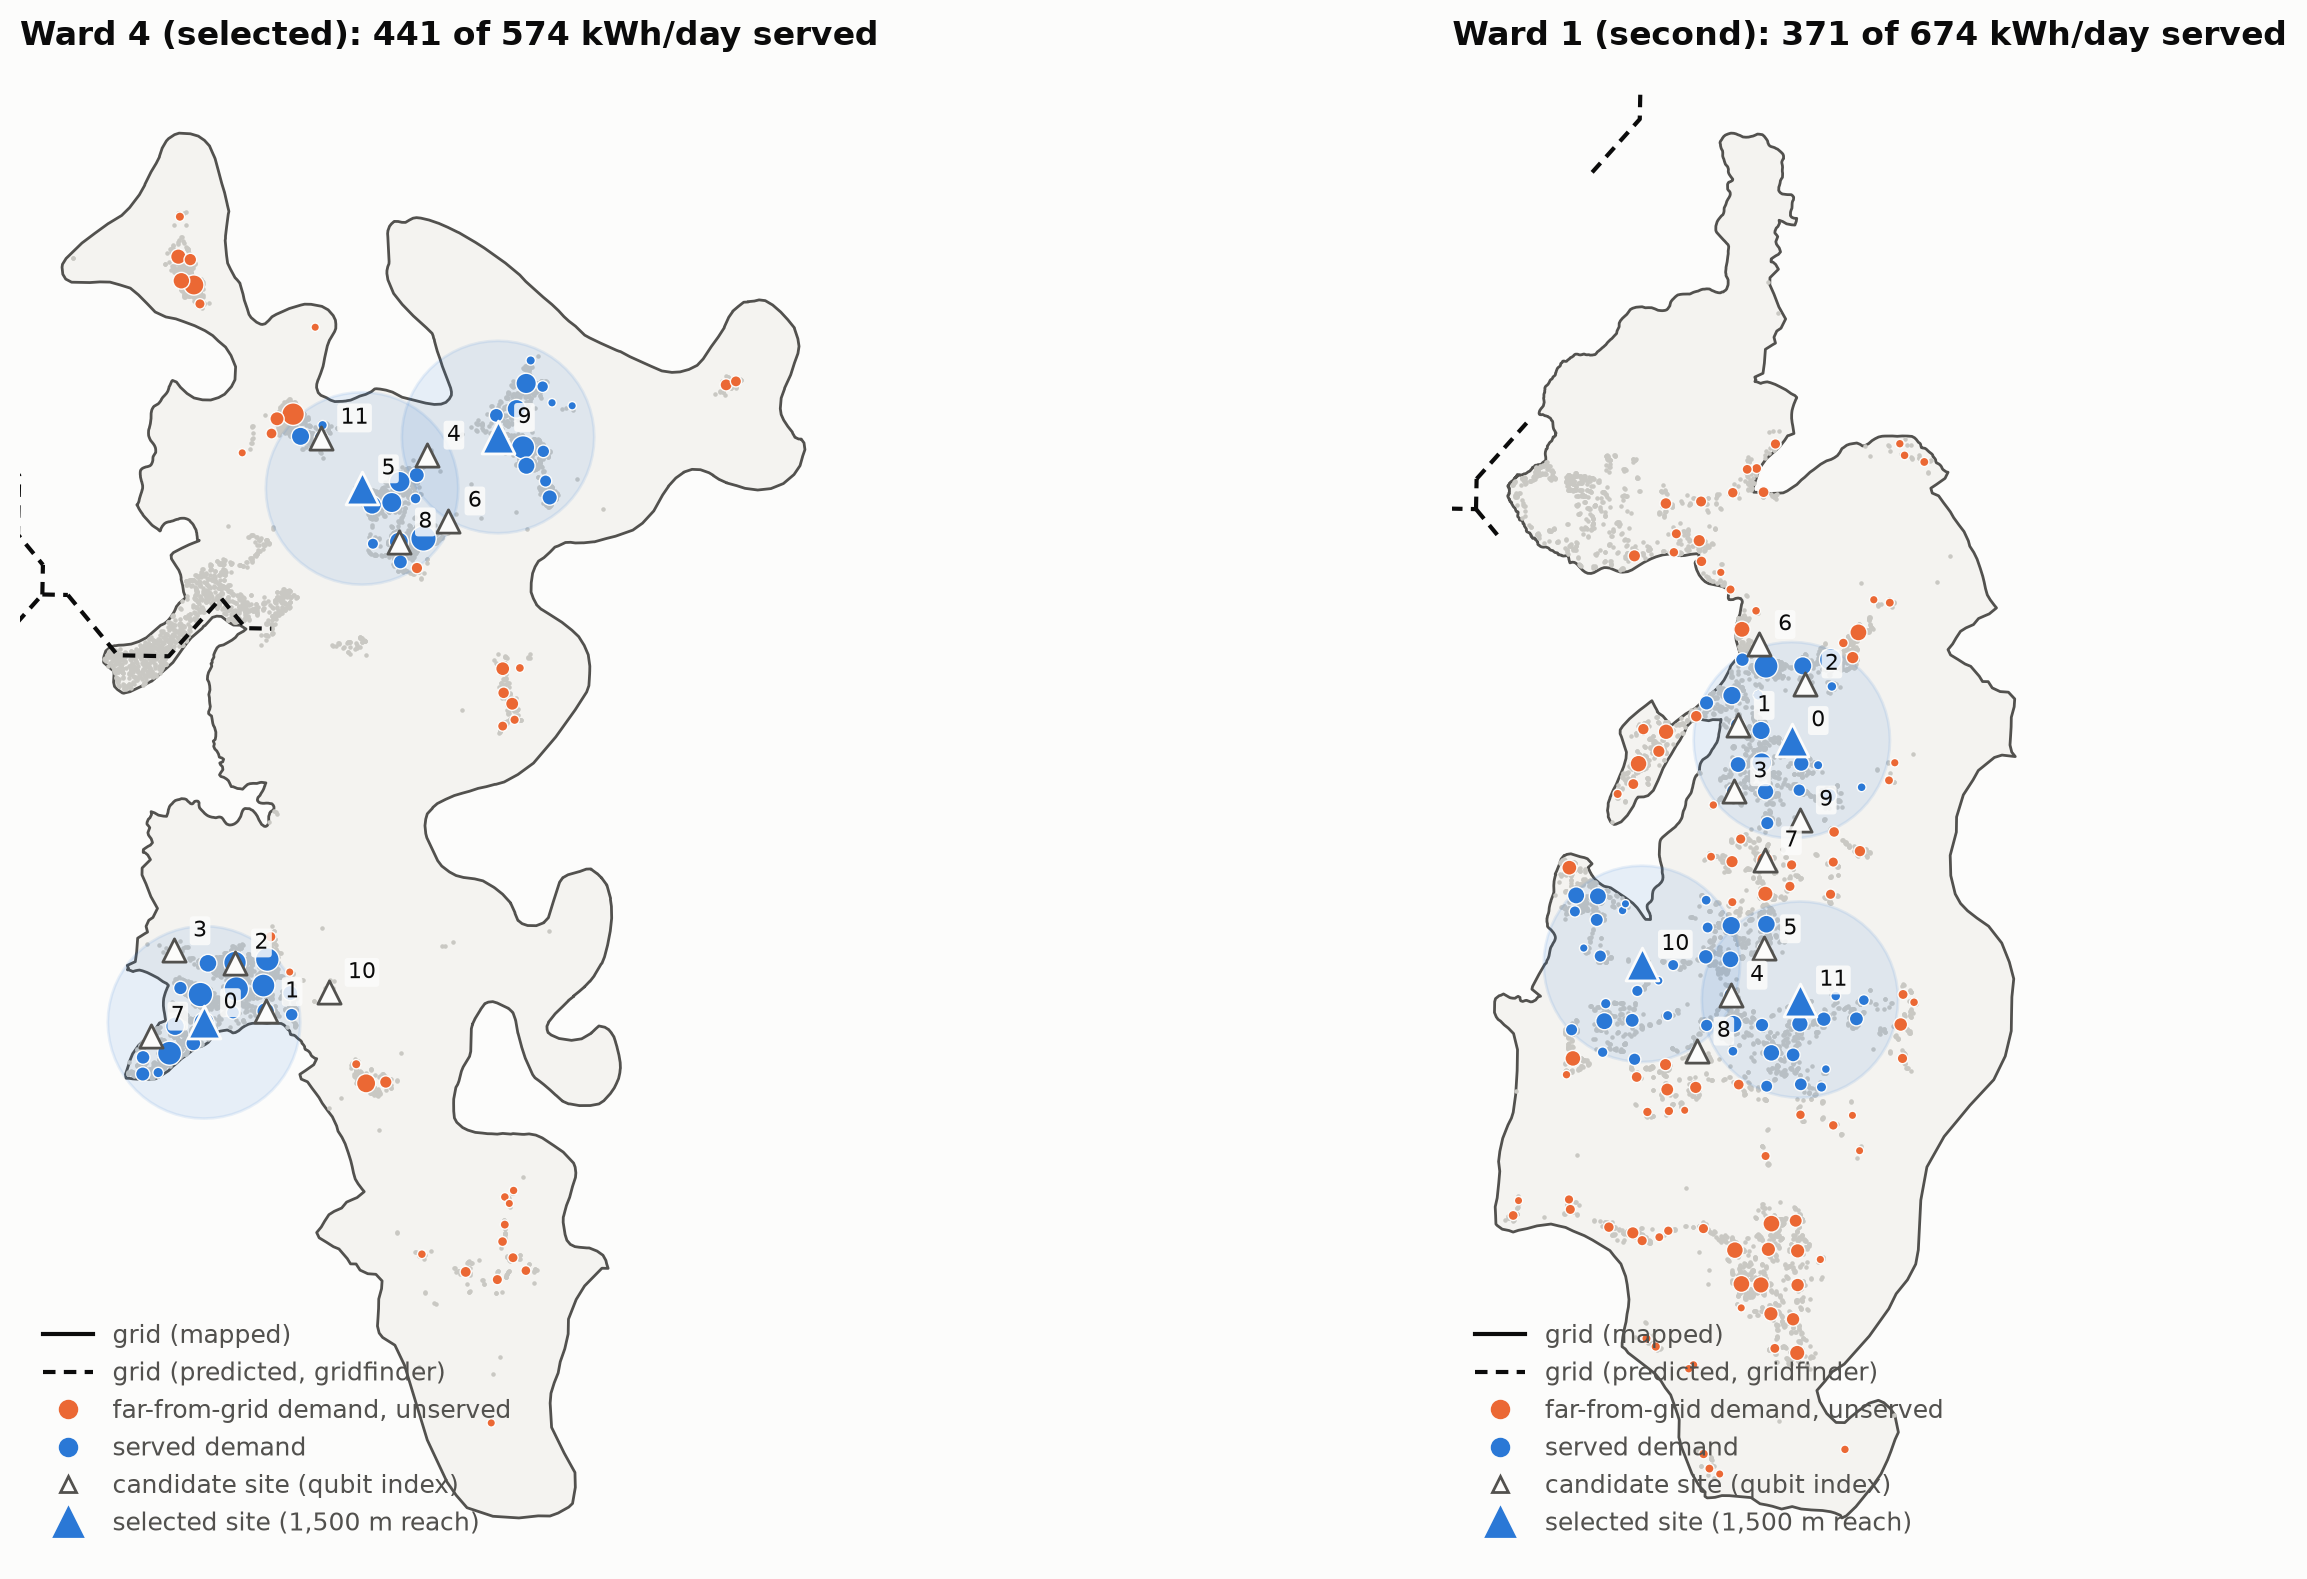

Ward 4: serves 441 kWh/day (77% of its far demand), rank 1 in 5 of 12 configs, greedy gap 6.2%
Ward 1: serves 371 kWh/day (55% of its far demand), rank 1 in 7 of 12 configs, greedy gap 2.7%

Selected ward: 4. pilot.ipynb uses cfg = PilotConfig(ward_no=4, ...)


In [11]:
second_ward = int(screen.index[1])
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ward_no, ax, tag in [(best_ward, axes[0], "selected"), (second_ward, axes[1], "second")]:
    plan = build_pilot(replace(cfg, ward_no=ward_no))
    x = solve_exact(plan.problem).x
    viz.plot_pilot(plan, x, ax=ax, title=f"Ward {ward_no} ({tag}): "
                   f"{plan.problem.served_demand(x):.0f} of {plan.problem.demand.sum():.0f} kWh/day served")
plt.tight_layout()
plt.show()

for ward_no in (best_ward, second_ward):
    r = screen.loc[ward_no]
    print(f"Ward {ward_no}: serves {r['served']:.0f} kWh/day ({r['served_share']:.0%} of its far demand), "
          f"rank 1 in {summary.loc[ward_no, 'times_best']} of {ranks.shape[1]} configs, "
          f"greedy gap {r['greedy_gap']:.1%}")
print(f"\nSelected ward: {best_ward}. pilot.ipynb uses cfg = PilotConfig(ward_no={best_ward}, ...)")